In [10]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

In [11]:
ds = xr.open_dataset("SENS_P01.950_N02.226_p4.62e-05_r10.8_14.nc")
print(ds)

<xarray.Dataset> Size: 26MB
Dimensions:          (particle: 200, time: 160, species: 100, nutrient: 1)
Coordinates:
  * particle         (particle) int32 800B 0 1 2 3 4 5 ... 195 196 197 198 199
  * time             (time) float64 1kB 0.0 2.16e+04 ... 3.413e+06 3.434e+06
  * species          (species) int32 400B 0 1 2 3 4 5 6 ... 93 94 95 96 97 98 99
  * nutrient         (nutrient) int32 4B 0
Data variables:
    ID               (particle) int32 800B ...
    Depth            (time, particle) float64 256kB ...
    Phytoplankton    (time, particle, species) float64 26MB ...
    Nutrient         (time, particle) float64 256kB ...
    Alpha            (species) float64 800B ...
    MaxPhotoRate     (species) float64 800B ...
    BasalMetabolism  (species) float64 800B ...
    HalfSaturation   (species) float64 800B ...
Attributes:
    description:  Aquacosm multi-species Lagrangian simulation
    dt:           5.0
    Ndays:        40
    Nspecies:     100
    Npts:         200


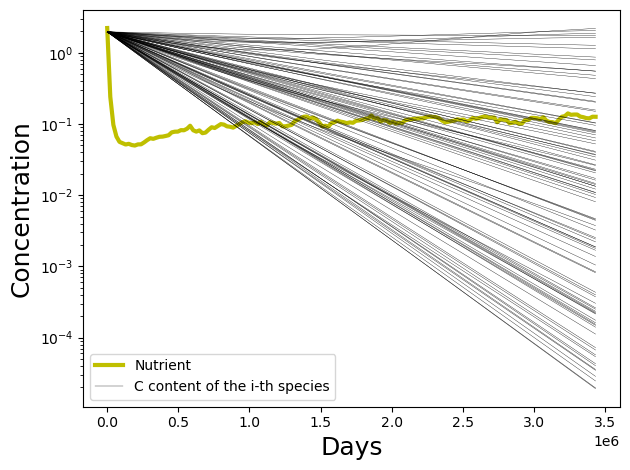

In [14]:
plt.semilogy(ds.time,  
             ds.Nutrient.mean(dim="particle"), 
             '-y',
             linewidth=3, 
             label="Nutrient")
for i in range(ds.Nspecies):
    plt.semilogy(ds.time,  
                 ds.Phytoplankton.isel(species=i).mean(dim="particle"), 
                 '-k',
                 linewidth=0.25)
plt.xlabel("Days", fontsize=18)
plt.ylabel("Concentration", fontsize=18)
plt.legend(['Nutrient', 'C content of the i-th species'], loc="lower left")
plt.tight_layout()

In [12]:
data=ds.Phytoplankton.isel(time=-1).mean(dim="particle").values
data.shape

(100,)

In [ ]:
ds.Phytoplankton.mean(dim="particle").plot()

In [13]:
ds.variables

Frozen({'ID': <xarray.Variable (particle: 200)> Size: 800B
[200 values with dtype=int32], 'Depth': <xarray.Variable (time: 160, particle: 200)> Size: 256kB
[32000 values with dtype=float64], 'Phytoplankton': <xarray.Variable (time: 160, particle: 200, species: 100)> Size: 26MB
[3200000 values with dtype=float64], 'Nutrient': <xarray.Variable (time: 160, particle: 200)> Size: 256kB
[32000 values with dtype=float64], 'Alpha': <xarray.Variable (species: 100)> Size: 800B
[100 values with dtype=float64], 'MaxPhotoRate': <xarray.Variable (species: 100)> Size: 800B
[100 values with dtype=float64], 'BasalMetabolism': <xarray.Variable (species: 100)> Size: 800B
[100 values with dtype=float64], 'HalfSaturation': <xarray.Variable (species: 100)> Size: 800B
[100 values with dtype=float64], 'time': <xarray.IndexVariable 'time' (time: 160)> Size: 1kB
array([      0.,   21600.,   43200.,   64800.,   86400.,  108000.,  129600.,
        151200.,  172800.,  194400.,  216000.,  237600.,  259200.,  280800

In [ ]:
ds.HalfSaturation.plot()

In [ ]:
ds.close()